# Módulo 2 — Procesamiento con Pandas

> Curso de Python para Análisis de Datos en Salud Pública — OPS/PAHO
> Material 2021, actualizado 2026.
> Licencia: código MIT, contenido CC-BY-SA 4.0.


# Módulo 4.2: Procesamiento intermedio de datos con Python y Pandas

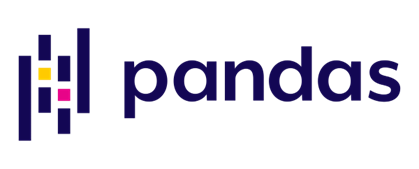

Más información en: 

[Pandas User Guide](https://pandas.pydata.org/docs/getting_started/intro_tutorials/index.html)

[Pandas Cheatsheet](https://pandas.pydata.org/Pandas_Cheat_Sheet.pdf)

## Estructuras de datos en Pandas

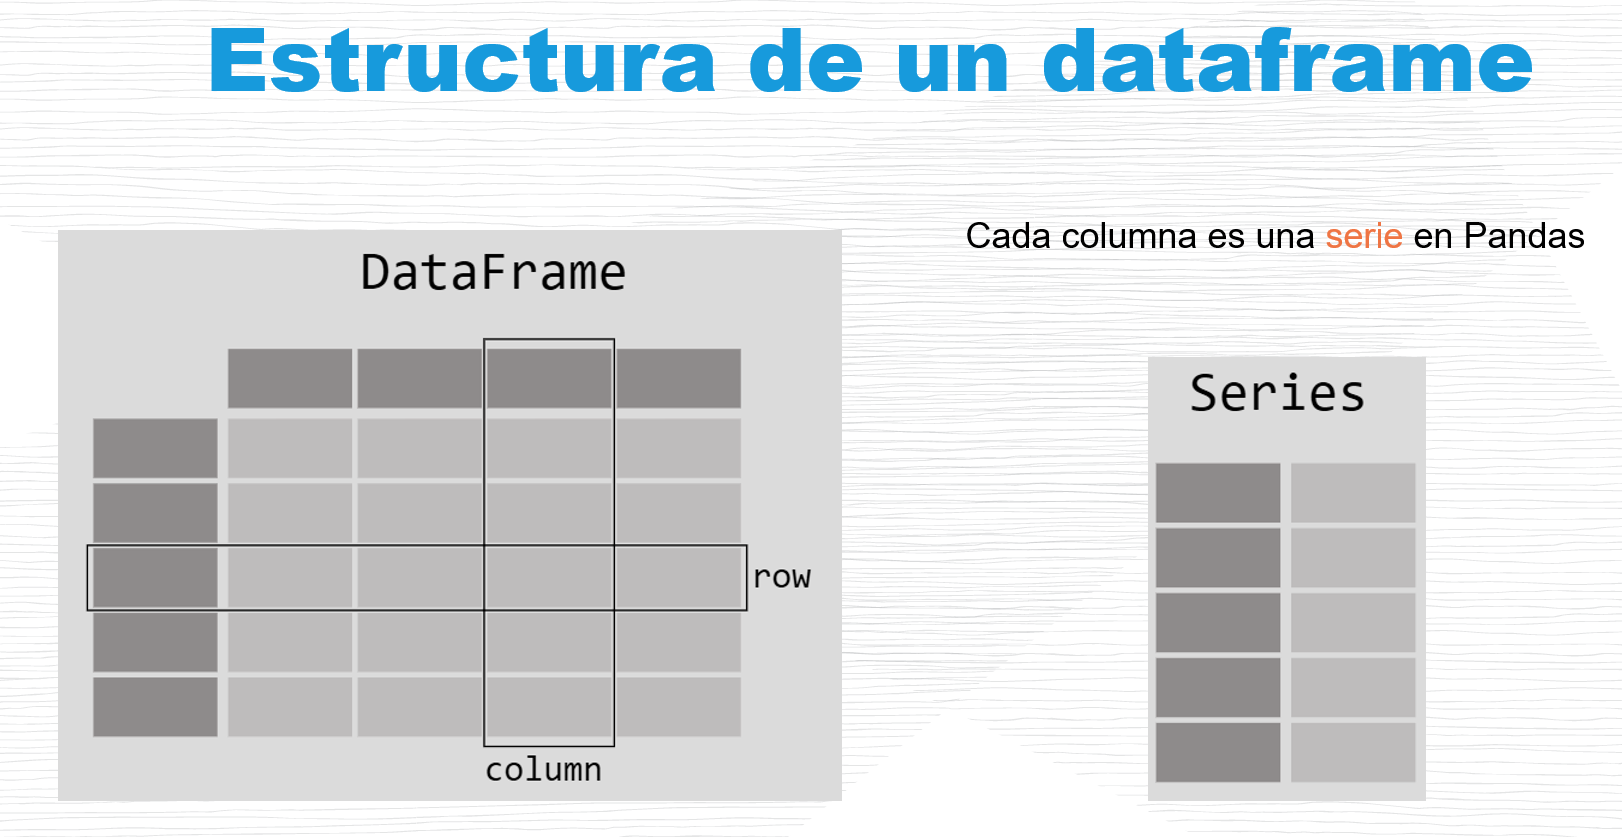


## Creando una serie

In [ ]:
# Importando las librerías
import pandas as pd
import numpy as np

In [ ]:
# Creando una serie
S = pd.Series([1,2,3,4,5])

# Creando una lista
L = [1,2,3,4,5]

In [ ]:
# Observando la lista
L

In [ ]:
#Observando la Serie
# La series tienen un índice que puede ser mutable
S

In [ ]:
# Cambiando el índice de una serie
S1 = pd.Series([1,2,3,4,5], index = ['a','b','c','d','e'])
S1

In [ ]:
# Se puede acceder a los elementos de una serie con su índice
S1["a"]

In [ ]:
# También con el número del elemento
# El primer elemento es el número cero
S1[0]

In [ ]:
# Se pueden extraer múltiples elementos introduciendo una lista en vez de un índice
# La lista corresponde al segundo corchete [0,2,4]
S1[[0,2,4]]

## Creando un dataframe


Más información sobre los métodos del DataFrame en:

[DataFrame Methods](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html)

In [ ]:
# Debemos importar la librería Pandas
import pandas as pd # Importa la librería Pandas
import numpy as np # Importa la librería Numpy

In [ ]:
# Podemos crear un dataframe con base en un diccionario
covid_cases = {
    'edad' :     [ 66, 66, 33, 43, 41, 51, 84,119,51,68,92,69],
    'sexo' : [ 'M', 'F', 'F', 'M', 'F', 'M', 'M','M','M','M','M','M'],
    'nac_pac' :   [ 'COLOMBIA','ECUADOR','COLOMBIA', 'ECUADOR', 'COLOMBIA', 'ECUADOR', 'PERÚ','COLOMBIA', 'ECUADOR', 'COLOMBIA', 'ECUADOR','COLOMBIA'],
    'area_ubi' :  [ 'Centro', 'Centro', 'Centro', 'Centro', 'Norte', 'Centro', 'Norte','Norte','Sur','Sur','Occidente','Oriente'],
    }
covid_cases

In [ ]:
# Se puede crear un data frame proporcionando los datos y estableciendo un índice. Si no se establece este será una sucesión de números
df = pd.DataFrame(covid_cases, index = ['Homero',"March","Magie",'Bart','Lisa','Lenny','Ned', 'Sr. Burns', 'Carl','Sr. Smithers','Krusty','Skinner'])
df

Fuente sobre la edad de los Simpsons: 

[The Simpsons: Every Main Character & How Old They'd Be If They Aged In Real Time](https://www.cbr.com/the-simpsons-main-characters-real-age/)

## Leyendo datos de una base

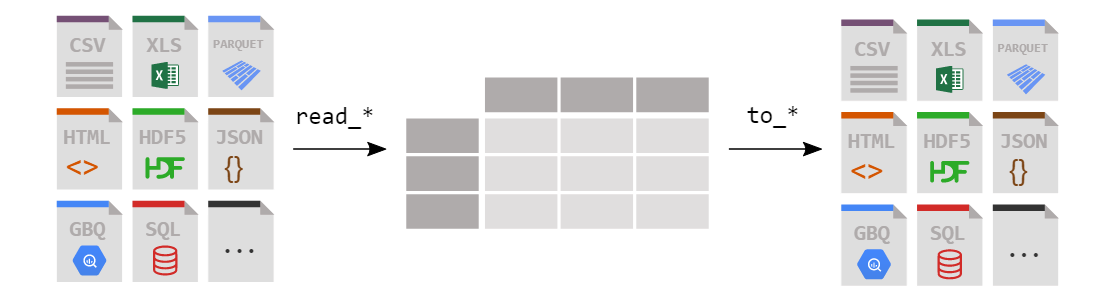

Más información en:


[Como leer datos tabulares](https://pandas.pydata.org/pandas-docs/stable/getting_started/intro_tutorials/02_read_write.html)

In [ ]:
# También podemos leer datos reales para crear un dataframe
# Pero primero debemos conectarnos a Google Drive para obtener acceso a las bases

## Conexión a Google Drive

In [ ]:
# Setup de rutas — funciona en local y en Colab.
from pathlib import Path
import os, sys

try:
    from google.colab import drive  # type: ignore
    drive.mount('/content/gdrive')
    DATA_DIR = Path('/content/gdrive/MyDrive/Curso_pandas')
except ImportError:
    # Local: usar el directorio data/ del repo
    DATA_DIR = Path.cwd().parent / 'data' if Path.cwd().name == 'notebooks' else Path.cwd() / 'data'

DATA_DIR.mkdir(parents=True, exist_ok=True)
print('DATA_DIR =', DATA_DIR)


In [ ]:
# Al montar Google Drive tenemos acceso a nuestros archivos
# Para gestionar los archivos es importante cargar la libreria Operative System u os
import os

In [ ]:
# Es importante leer el directorio de trabajo y/o establecer el que deseamos
# El comando getcwd significa get current working directory
# Estoy en la ubicación content

os.getcwd()

In [ ]:
# También podemos usar el comando de Linux
%pwd

Google Colab tiene un gestor de archivos que nos permite navegar entre nuestras carpetas


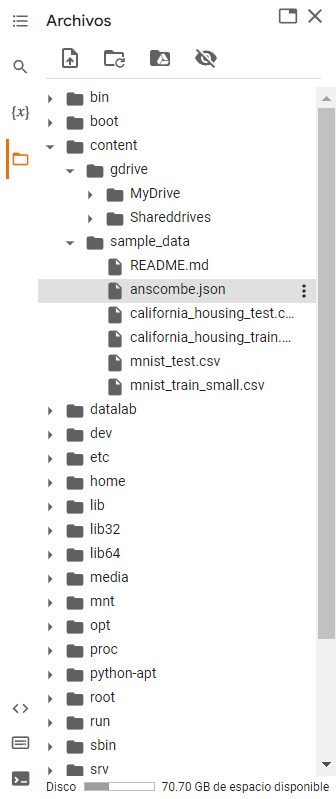

In [ ]:
# DATA_DIR ya fue creado arriba — saltar chdir global.
os.chdir(DATA_DIR)


In [ ]:
# Carpeta de trabajo ya existe (DATA_DIR). Esta celda se conserva como referencia.
# (DATA_DIR / 'Curso_pandas').mkdir(exist_ok=True)


In [ ]:
# Ya estamos en DATA_DIR.


In [ ]:
# Confirmamos que entramos al directorio
os.getcwd()

## Descargando datos directamente en Google Drive

In [ ]:
# Vamos a descargar datos de egresos y camas hospitalarias del Ecuador
url = 'https://www.ecuadorencifras.gob.ec/documentos/web-inec/Estadisticas_Sociales/Camas_Egresos_Hospitalarios/Cam_Egre_Hos_2021/Datos_abiertos_camas_egresos_hospitalarios_2021.zip'


In [ ]:
# obteniendo los datos
# Con la variable !wget descargamos datos desde otras direcciones. Estos datos se almacenan en nuestro directorio de trabajo
!wget https://www.ecuadorencifras.gob.ec/documentos/web-inec/Estadisticas_Sociales/Camas_Egresos_Hospitalarios/Cam_Egre_Hos_2021/Datos_abiertos_camas_egresos_hospitalarios_2021.zip -nH --cut-dirs=100 -p 

In [ ]:
# Con !ls listamos los archivos que tenemos disponibles
%ls

In [ ]:
# Necesitamos recordar el directorio donde estamos para descomprimir ahí el archivo
os.getcwd()

In [ ]:
# Descomprimir el archivo en DATA_DIR (portable Colab/local).
import subprocess, sys
zip_path = DATA_DIR / 'Datos_abiertos_camas_egresos_hospitalarios_2021.zip'
subprocess.run(['unzip', '-q', '-o', str(zip_path), '-d', str(DATA_DIR)], check=True)
print('Descomprimido en', DATA_DIR)


In [ ]:
# Podemos revisar que se haya descomprimido exitosamente
!ls

In [ ]:
# Vemos que existen dos carpetas, vamos a listar los elementos en EEH
!ls '2. Datos_abiertos_EEH_2021'

In [ ]:
# Vamos a leer el archivo .csv de egresos hospitalarios
df = pd.read_csv(f'{DATA_DIR}/2. Datos_abiertos_EEH_2021/egresos_hospitalarios_2021.csv',  sep = ";")

## Explorando la base de datos

Notar que pueden variar los resultados si se utiliza el dataframe de los Simpsons o los datos de Google Drive

### Exploración inicial de un DataFrame

In [ ]:
# Podemos visualizar las primeras observaciones del dataframe
# Si no especificamos el número de filas se seleccionan las primeras 5
df.head(7)

In [ ]:
# Podemos visualizar las últimas observaciones
df.tail(3)

In [ ]:
# Podemos ver las dimensiones del dataframe
# Vemos la cantidad de filas y columnas
df.shape


In [ ]:
# Podemos ver el nombre de las columnas o variables con el método columns
df.columns

In [ ]:
# Podemos revisar el índice con su método respectivo
df.index

In [ ]:
# Podemos obtener un resumen de la información del dataframe
df.info()

In [ ]:
# Podemos revisar el tipo de variable
df.dtypes

In [ ]:
# Podemos ver cuántos valores únicos tiene cada variable
df.nunique()

### Cambiando el formato de datos

In [ ]:
# Podemos hacer un cambio automático de los tipos
# Vemos que cambiaron las variables a string 
# Pero el tipo object es más ligero
df.convert_dtypes(infer_objects=True).info()

In [ ]:
# Cambiamos el dataframe
# Sirve solo para el dataframe con los datos leídos del Drive
df[['sexo','nac_pac','area_ubi']]     =   df[['sexo','nac_pac','area_ubi']].astype('category')
df.dtypes

In [ ]:
df.info()

### Describiendo los datos

In [ ]:
# Podemso obtener una descripción de los datos
# Esta nos proporciona un resumen de las variables numéricas
df.describe()

In [ ]:
# Podemos cambiar la forma en la que se visualizan los números
# Inicialmente aparecen en notación científica
# Podemos cambiarlo a decimales

# Con lambda aplicamos una función para ver 5 dígitos tras el decimal
pd.set_option('display.float_format', lambda x: '%.5f' % x)


In [ ]:
# Vemos que la edad promedio es 37.59 años
df.describe()

In [ ]:
# Podemos explorar si hay valores faltantes
df.isna()

In [ ]:
# Pero es mejor obtener la sumatoria de datos faltantes
# Podemos concatenar dos métodos
# Vemos que no hay valores faltantes
df.isna().sum()

In [ ]:
# Podemos ordenar los datos según una columna
df.sort_values('edad', ascending=False)[['area_ubi','sexo','edad']]

In [ ]:
# Podemos renonmbrar una columna
# Debemos pasar un diccionario con el nombre antiguo y nuevo
df.rename(columns={'area_ubi':'area_u'}).head()

In [ ]:
# ¿Por qué no se ha guardado el nombre?
df.head()

In [ ]:
# Debemos guardar el nuevo valor como df
df = df.rename(columns={'area_ubi':'area_u'})


In [ ]:
# Vemos que ya se cambió el nombre
df.head()

In [ ]:
# Restablecemos el nombre original
df = df.rename(columns={'area_u':'area_ubi'})

Puede explorar los demás métodos en https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html

In [ ]:
# Podemos observar la cantidad de valores según las categorías de una variable
# Hay 15.228 personas nacidas en Venezuela

df['area_ubi'].value_counts()

In [ ]:
# Se pueden aplicar métodos a las variables numéricas para obtener datos puntuales
df['edad'].mean()

In [ ]:
df['edad'].max()

## Filtrando el dataframe

In [ ]:
# Podemos seleccionar secciones del dataframe con los métodos tradicionales de indexación
# Podemos seleccionar una columna por su nombre
df['edad']

In [ ]:
# También podemos seleccionar una variable como si fuera un método
# Esta opción no es recomendable porque pueden existir métodos con nombres similares a las variables
df.edad

In [ ]:
# Podemos seleccionar diversas columnas 
# Para esto pasamos una lista con el nombre de las variables, la lista es ['edad','sexo']
df[['edad','sexo']]

In [ ]:
# Podemos seleccionar diversas variables de un mismo índice
# Para esto utilizamos el método loc que localiza los datos con base en las etiquetas

# df.loc[1,['edad','sexo']] # Funciona con los datos del Drive
df.loc['Homero',['edad','sexo']]

In [ ]:
# Podemos agregar una lista de índices y una lista de columnas

#df.loc[[2,3],['edad','sexo']] # Funciona con los datos del Drive

df.loc[['Homero','Lisa'],['edad','sexo']]

In [ ]:
# Con dos puntos podemos seleccionar todos los índices
df.loc[:,['edad','sexo']]

In [ ]:
# df.loc[[3,2],:] # Funciona con los datos de Drive
df.loc[['Homero','Lisa'],:]

In [ ]:
# Podemos seleccionar celdas específicas con base en los integers con iloc

df.iloc[0,0]

In [ ]:
df

In [ ]:
# Seleccionamos a Magie, Lisa y Lenny y vemos su sexo y estado
df.iloc[[2,4,5],[1,3]]

In [ ]:
df

In [ ]:
# Podemos utilizar también los dos puntos
df.iloc[:,[1,2]]

In [ ]:
df.iloc[[0,1],:]

In [ ]:
# Podemos acceder directamente a una celda con sus etiquetas

# df.at[1,'edad'] # Funciona con los datos de Drive
df.at['Homero','edad']

In [ ]:
# Podemos acceder a los datos de un índice
#df.xs(1) # Funciona con los datos de Drive
df.xs('Homero')

In [ ]:
# Podemos ver la cantidad de filas según los elementos de una variable

df['sexo'].value_counts() 

In [ ]:
# Veamos el porcentaje
# Usamos la función len que indica el largo o cantidad de filas
df['sexo'].value_counts() / len(df) 

In [ ]:
# Podemos establecer el porcentaje ya multiplicado por 100
df['sexo'].value_counts() / len(df)  * 100

In [ ]:
# Con filter podemos filtrar por etiquetas, expresiones regulares o el contenido
df.filter(items=['sexo','nac_pac'])

In [ ]:
# También podemos utilizar expresiones regulares y establecer el eje (axis)
# Para que aplique en filas (axis=0) o columnas (axis=1)
# Obtiene los elementos terminados en s según el índice de la fila

#df.filter(regex='e$', axis=1) # Si se usan los datos de Drive
df.filter(regex='s$', axis=0)

Más información sobre expresiones regulares en:

[An Introduction to Regular Expressions](https://towardsdatascience.com/an-introduction-to-regular-expressions-5dd762afc5e4)

In [ ]:
# También podemos indicar que queremos seleccionar según el contenido
# de las etiquedas estableciendo el valor similar que queremos
# Buscamos las filas cuyo índice contenga ar y obtenemos March, Bart y Carl

#df.filter(like='se', axis=1) # Si se usan los datos de Drive
df.filter(like='ar', axis=0)

## Filtrando la base de forma condicional

In [ ]:
# Podemos filtrar la base de datos pasando una variable y un condicional dentro de los []
# Filtramos la base para obtener los datos de los menores de 50 años

df[df['edad']<50]['edad']

In [ ]:
df[df['edad']<50].describe()

In [ ]:
# Podemos complejizar el filtro para añadir diversas condiciones, pero utilizamos paréntesis
# Filtramos a las personas menores de 50 que viven en Colombia
df[(df['edad']<50) & (df['nac_pac']=='COLOMBIA')]

In [ ]:
df['nac_pac'].value_counts()

In [ ]:
# El método Query permite filtrar el dataframe indicando directamente las condiciones
df.query('edad < 50')['edad'].describe()

## Unión de dataframes

En ocasiones podemos contar con diversas bases de datos sobre una misma temática, por lo cual podría ser necesario unirlas.

Pandas permite concatenarlas y unirlas.

Más información en:

 [Merging DataFrames with pandas](https://medium.com/swlh/merging-dataframes-with-pandas-pd-merge-7764c7e2d46d)

 [How to combine data from multiple tables?](https://pandas.pydata.org/docs/getting_started/intro_tutorials/08_combine_dataframes.html)

Los datos se pueden concatenar (añadir nuevas filas) o unir (agregar columnas). En el primer caso basta con tener las columnas con el mismo nombre, pero en el segundo es necesario contar con un identificador común que permita asociar las filas de una base y otra.

**Concatenación:**


---

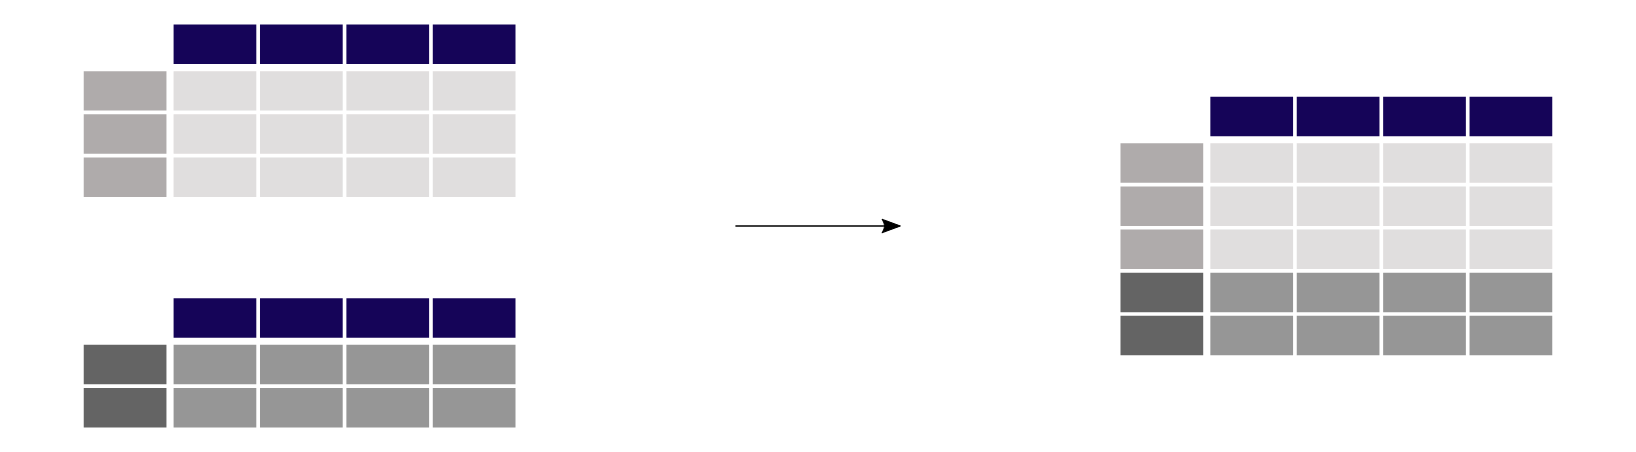

**Unión:**



---



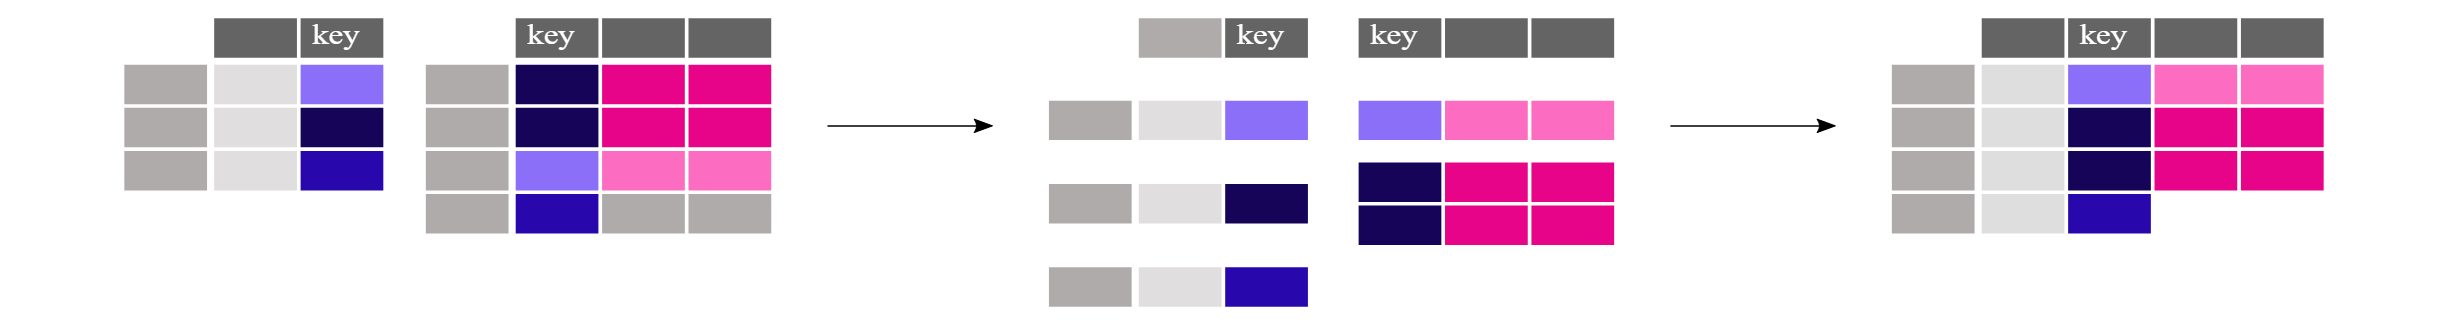



### Concatenación de datos

In [ ]:
# Vamos a utilizar nuestro ejemplo de los Simpsons

In [ ]:
# Datos del primer dataframe
# Podemos imaginar que estos datos corresponden al 2021
covid_cases = {
    'edad' :     [ 66, 66, 33, 43, 41, 51, 84,119,51,68,92,69],
    'sexo' : [ 'M', 'F', 'F', 'M', 'F', 'M', 'M','M','M','M','M','M'],
    'nac_pac' :   [ 'COLOMBIA','ECUADOR','COLOMBIA', 'ECUADOR', 'COLOMBIA', 'ECUADOR', 'PERÚ','COLOMBIA', 'ECUADOR', 'COLOMBIA', 'ECUADOR','COLOMBIA'],
    'area_ubi' :  [ 'Centro', 'Centro', 'Centro', 'Centro', 'Norte', 'Centro', 'Norte','Norte','Sur','Sur','Occidente','Oriente'],
    }


In [ ]:
# Formato en DataFrame
df = pd.DataFrame(covid_cases, index = ['Homero',"March","Magie",'Bart','Lisa','Lenny','Ned', 'Sr. Burns', 'Carl','Sr. Smithers','Krusty','Skinner'])
df

In [ ]:
# Ahora registraremos los casos de 2022
covid_cases_22 = {
    'edad' :     [42,70,45,63,77,68,76,71,71],
    'sexo' : [ 'M','F','M','M','M','M','M','F','F'],
    'area_ubi' :  ['Oriente','Occidente','Oriente','Sur','Centro','Oriente','Centro','Sur','Sur'],
    'nac_pac' :   ['PERÚ','VENEZUELA','PERÚ','INDIA','VENEZUELA','VENEZUELA','ESCOCIA','ECUADOR','ECUADOR'],
    
    }

In [ ]:
df_22 = pd.DataFrame(covid_cases_22, index = ['Milhouse','Edna Krabappel','Nelson','Apu','Moe','Jefe Górgory','Willie','Patty','Selma'])
df_22

In [ ]:
# Utilizo la función concat y en una lista enuncio las tablas a concatenar
# Notar que entre los df la columna nac_pac y area_ubi están en posiciones distintas
# Esto no afecta el resultado final
# Utilizo el atributo axis para especificar si quiero que se concatenen filas o columnas

df_completo = pd.concat([df,df_22], axis=0)
df_completo

In [ ]:
# Vemos que se han adicionado datos
df_completo.shape

### Unir dataframes o añadir columnas

Para añadir columnas a un dataframe podemos concatenarlas, pero si estas columnas corresponden a individuos específicos necesitamos una variable común que identifique a los individuos. Estas son las variables de identificación o variables llave

In [ ]:
# Vamos a crear un nuevo dataframe con una variable adicional. 
# Nuestra variable llave será el index o nombre de los individuos
df_extra = pd.DataFrame(
    {
        'gravedad':[1,1,1,0,0,1,0,1,0,1,0,1,0,1,0,1,1,1,0,0,1,0]
    }
    , index = ['Homero',"March","Magie",'Bart','Lisa','Lenny','Ned', 'Sr. Burns', 'Carl','Sr. Smithers','Krusty','Skinner',
               'Milhouse','Edna Krabappel','Nelson','Apu','Moe','Jefe Górgory','Willie','Patty','Selma','Gordo Tony']
    )
df_extra

In [ ]:
# Para unir dos bases usamos la función merge
# En la opción how podemos establecer 
pd.merge(df_completo,df_extra,how='inner',right_index=True,left_index=True)

In [ ]:
# Vamos a grabar la nueva base
df = pd.merge(df_completo,df_extra,how='inner',right_index=True,left_index=True)

En la opción how podemos establecer como queremos que se peguen los datos. Si pegamos los que coinciden (inner), si pegamos y mantenemos los de la izquiera (left) o derecha (right), o si mantenemos todos los datos (outer).

Podemos notar que el resultado del Gordo Tony no se pegó porque usamos inner. Pero veamos que sucede al usar el right join

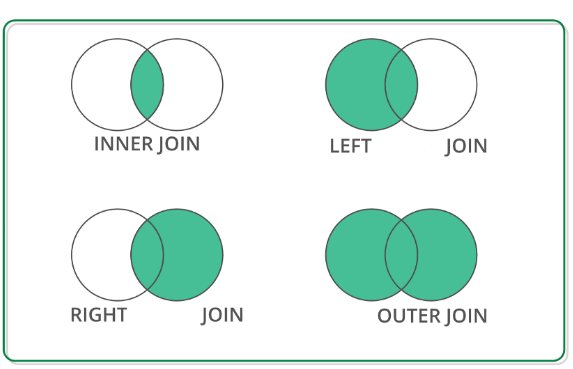

In [ ]:
# Vemos que aparece el Gordo Tony pero sin los datos de la izquierda porque estos no existen
pd.merge(df_completo,df_extra,how='right',right_index=True,left_index=True)

## Agrupando datos para análisis

In [ ]:
# Podemos agrupar los datos según una columna
# Agrupamos por sexo, seleccionamos la edad 
# Establecemos que queremos el promedio
# Se usan [] para seleccionar variables
df.groupby('sexo')[['edad']].mean()

In [ ]:
# Podemos agrupar por otras variables
# Veamos la edad promedio en función de la gravedad
# Vemos que las personas con un cuadro grave tienen una edad superior
df.groupby('nac_pac')[['edad']].count()

In [ ]:
# Podemos utilizar las funciones de Numpy
# Veamos la desviación estándar de la edad
# Vemos que hay una menor desviación estándar de la edad
# en las personas con cuadros graves

# Podemos aplicar funciones de Numpy o las que creemos directamente
df.groupby('nac_pac')[['edad']].apply(np.std)



Más información sobre las funciones estadísticas de Numpy

[Funciones estadísticas](https://numpy.org/doc/stable/reference/routines.statistics.html)

In [ ]:
# Podemos agrupar los datos con varios criterios
# Agrupamos los datos por sexo y gravedad
# Con la función aggreate podemos establecer qué funciones queremos mostrar
# Seleccionamos de Numpy la media, desviación estándar, mínimo y máximo
df.groupby(['nac_pac','sexo'])[['edad']].aggregate([np.mean,np.std,np.min,np.max])

## Creación de variables adicionales

In [ ]:
# A veces necesitamos hacer análisis con un criterio distinto
# al presente en las variables
# Por ello es necesario a veces generar nuevas variables

# Haremos una nueva clasificación de las edades
pd.cut(df['edad'],bins = [0,5,11,18,26,60,200])

In [ ]:
# Para añadir la columna debemos seleccionar el dataframe
# Seleccionar el nombre de la variable que tendrá y asignarle este valor
df['rango_edad']=pd.cut(df['edad'],bins =  [0,5,11,18,26,60,200])

In [ ]:
# Observamos que tenemos nuestra nueva variable categórica 
# con base en datos numéricos
df[['edad','rango_edad']]

In [ ]:
# Veamos cuántas observaciones hay por rango
# Vemos que no hay personas entre 70 y 80 años
df['rango_edad'].value_counts()

In [ ]:
# Podemos verlos con una agrupación
# Podemos ver el promedio de la edad en el rango y el conteo de individuos
df.groupby(['rango_edad'])[['edad']].aggregate([np.mean,np.count_nonzero,np.min,np.max])

In [ ]:
# También podemos crear variables binarias a partir de una categórica
# Las variables binarias o Dummies identifican una cualidad por columna
# Vemos que no hay personas entre 70 y 80 años
df['nac_pac'].value_counts()


In [ ]:
# Creando las variables dummy
pd.get_dummies(df['nac_pac'])

In [ ]:
# Podemos crear variables según condiciones
#np.where(<Condición>,<Valor si verdadero>,<Valor si falso>)

np.where((df['gravedad']==1) & (df['edad']>65), 'Alto Riesgo','Riesgo Moderado')

In [ ]:
df['Riesgo'] = np.where((df['gravedad']==1) & (df['edad']>65), 'Alto Riesgo','Riesgo Moderado')
df

In [ ]:
# También podemos hacer operaciones matemáticas
# Y asignarlo a una nueva variable
df['edad']/df['gravedad'] 

In [ ]:
# También podemos aplicar funciones para crear una nueva variable
# Usamos la potencia con Numpy
np.power(df['edad'],3)

In [ ]:
# Podemos aplicar funciones a una fila específica
# La función lambda permite definir cómo queremos transformar los datos
# Siendo x los datos originales
df['edad'].apply(lambda x : x*12) # Obtenemos la edad en meses

In [ ]:
# También podemos condicionar la función lambda
# Aplicamos la función cuando la variable cumple una función, 
# sino aplicamos otra

df['edad'].apply(lambda x : x*12 if x<50 else x*-1) 

## Tablas dinámicas

In [ ]:
# Queremos saber cuantas personas colombianas fueron atendidas por cantón y la edad promedio de los pacientes
# Tomamos como valor el cantón, con la función de agregación contamos esta variable. Mostramos los resultados por el índice
pd.pivot_table(df, values='edad', index=['nac_pac'],
                    columns=['area_ubi'], aggfunc='count') # Si usamos los datos de Drive



In [ ]:
# Queremos saber cuántas personas se atendieron por provincia y sexo
pd.pivot_table(df, values='edad', index=['area_ubi'],
                    columns=['sexo'], aggfunc='count') # Si usamos los datos de Drive

In [ ]:
# Queremos saber la edad promedio de personas se atendieron por provincia y sexo
pd.pivot_table(df, values='edad', index=['area_ubi'],
                    columns=['sexo'], aggfunc='mean') 

In [ ]:
# Queremos exportar esta tabla
# Queremos saber la edad promedio de personas se atendieron por provincia y sexo
tab1=pd.pivot_table(df, values='edad', index=['area_ubi'],
                    columns=['sexo'], aggfunc='mean')

In [ ]:
tab1.to_csv('tabla1.csv')

In [ ]:
!ls

## Manipulando el índice de un dataframe


In [ ]:
# Podemos ver el índice de un DataFrame
df.index

In [ ]:
# En ocasiones es probable que deseemos tener el índice como una variable
# y cambiar el índice original por una cuenta normal
# Observamos que se creó una variable index
df.reset_index()

Recordar que para que este resultado quede guardado, es necesario asignarlo al objeto original de la siguiente forma:

df = df.reset_index()

In [ ]:
# Es probable que no queramos reiniciar el índice, pero que lo necesitemos como una variable
# Podemos crear una nueva variable de este modo

df['nombre'] = df.index
df

In [ ]:
# En otras ocasiones tendremos más de un índice, es decir
# un índice de varios niveles
# Esto ocurre cuando hacemos agrupaciones o tablas dinámicas
tabla = df.groupby(['sexo','Riesgo'])[['edad']].mean()
tabla

In [ ]:
# Podemos ver que el índice es una serie de tuplas
tabla.index

In [ ]:
# Podemos obtener los valores por niveles
# Así obtenemos el primer nivel
tabla.index.get_level_values(0)

In [ ]:
# Y obtenemos el segundo nivel
tabla.index.get_level_values(1)

## Resumen de métodos más utilizados en Pandas

In [ ]:
# Métodos más usados en pandas
import pandas as pd #Importa la librería Pandas

df.head()         # Muestra las primeras filas
df.tail()         # Muestra las últimas filas
df.shape          # Muestra el número de filas y columnas (sin paréntesis)
df.columns()      # Muestra el nombre de las columnas
df.index          # Muestra el índice de las filas (sin paréntesis)
df.info()         # Muestra información del dataframe
df.dtypes         # Muestra el tipo de variable (sin paréntesis)
df.describe()     # Describe los valores numéricos

df.isna()         # Muestra si hay valores faltantes
df.isna().sum()   # Muestra la suma de valores faltantes
df.nunique()      # Muestra el número de valores únicos de las variables
df.sort_values()  # Ordena los valores según una columna
df.rename()       # Cambia el nombre de una columna
df.loc()          # Localiza una sección con base en etiquetas de filas y columnas
df.iloc()         # Localiza una sección con base en números de filas y columnas
df.at()           # Accede a los datos de una celda con base en etiquetas
df.xs()           # Accede a los datos de un índice

df['sexo'].value_counts()   # Cuenta la cantidad de valores de una variable
df.filter()       # Filtra el dataframe según una expresión regular
df.query()        # Filtra el dataframe según una condición
df.groupby()      # Agrupa los datos por una columna
df.pivot_table()  # Elabora una tabla dinámica
df.drop()         # Elimina columnas

df.to_csv('nombre.csv')               # Exporta en CSV con el nombre
df.to_excel('nombre.xlsx')            # Exporta en Excel
df.to_parquet('nombre.parquet.gzip')  # Exporta en Parquet
df.to_pickle('nombre.pkl')            # Exporta en Parquet



## Series de tiempo con Pandas

Las series de tiempo son colecciones de observaciones sobre un
determinado fenómeno efectuadas en sucesivos momentos del tiempo,
usualmente equiespaciados  [(Hernández - CEPAL, 2015)](https://www.cepal.org/sites/default/files/courses/files/01_1_conociendo_una_serie_de_tiempo.pdf).


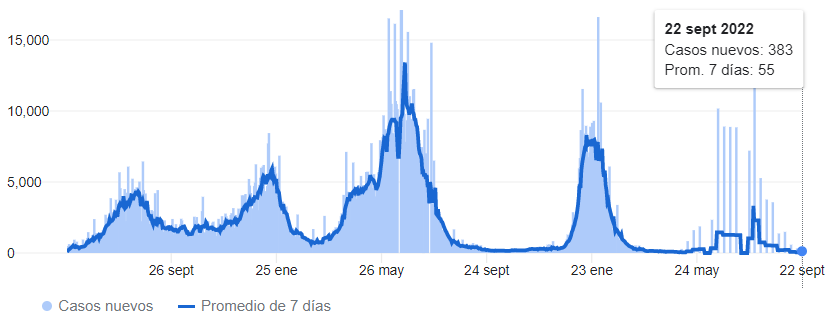


Python también permite procesar datos temporales (series de tiempo)
Para este ejemplo utilizaremos datos de Humanitarian Data Exchange (HDX) sobre COVID-19.

### Obteniendo los datos

In [ ]:
# Importando librerías y configurando rutas
import pandas as pd
import numpy as np
import os
from pathlib import Path

try:
    from google.colab import drive  # type: ignore
    drive.mount('/content/gdrive')
    DATA_DIR = Path('/content/gdrive/MyDrive/Curso_pandas')
except ImportError:
    DATA_DIR = Path.cwd().parent / 'data' if Path.cwd().name == 'notebooks' else Path.cwd() / 'data'


In [ ]:
# Revisamos nuestro directorio de trabajo
os.getcwd()

In [ ]:
os.chdir(DATA_DIR)
os.getcwd()


In [ ]:
# Revisamos los documentos
!ls

Buscamos los datos de COVID-19 en Humanitarian Data Exchange

[WHO - Coronavirus (COVID-19) Cases and Deaths](https://data.humdata.org/dataset/coronavirus-covid-19-cases-and-deaths)

In [ ]:
# Obtenemos la url de los datos
url_covid = 'https://covid19.who.int/WHO-COVID-19-global-data.csv'

In [ ]:
# Obtenemos los datos con wget
!wget https://covid19.who.int/WHO-COVID-19-global-data.csv -nH --cut-dirs=100 -p 

In [ ]:
# Revisamos que se hayan descargado los datos
!ls

### Formateando los datos con Pandas

In [ ]:
# Leemos los datos
covid = pd.read_csv('https://covid19.who.int/WHO-COVID-19-global-data.csv')

In [ ]:
# Observamos los datos
covid

In [ ]:
# Obtenemos información de los datos
# Es necesario cambiar el formato de fecha
# La base pesa más de 14 megabytes
covid.info()

In [ ]:
# Veamos la cantidad de valores únicos para identificar variables categóricas
# Las variables Country_code, Country y WHO_region se pueden cambiar a categóricas
covid.nunique()

In [ ]:
# Cambiamos el formato de la fecha
covid['Date_reported'] = pd.to_datetime(covid['Date_reported'])
covid['Date_reported']

In [ ]:
# Se observa que la nueva base de datos es más ligera
covid[['Country_code', 'Country' , 'WHO_region']] = covid[['Country_code', 'Country' , 'WHO_region']].astype('category')
covid.info()

### Procesando los datos con Pandas

Más información en:


[Working with Time Series](https://jakevdp.github.io/PythonDataScienceHandbook/03.11-working-with-time-series.html#:~:text=Pandas%20Time%20Series%20Data%20Structures&text=For%20time%20stamps%2C%20Pandas%20provides,associated%20Index%20structure%20is%20DatetimeIndex%20.)

[Time series / date functionality](https://pandas.pydata.org/docs/user_guide/timeseries.html)



In [ ]:
# En un próximo módulo veremos la librería Seaborn para visualizar datos
# Por el moemnto utilizaremos pyplot
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
import datetime

sns.set()

In [ ]:
# Podemos agrupar los datos por fecha y región y obtener la sumatoria

covid.groupby(['Date_reported','WHO_region']).sum()

In [ ]:
# Por simplicidad, usaremos los datos agregados mundiales
covid_agg=covid.groupby(['Date_reported']).sum()
covid_agg

In [ ]:
# Observación de los casos de COVID-19
covid_agg['New_cases'].plot()
plt.show()

In [ ]:
# Podemos suavizar los datos para verlos más claros
# Para esto calculamos la media móvil con el método rolling
# Vamos a calcular la media móvil de 7 días

rolling = covid_agg['New_cases'].rolling(7, center=True)
rolling.mean().head(20)

In [ ]:
# Podemos visualizar la media móvil con un gráfico de pyplot
rolling.mean().plot()
plt.show()

Podemos crear gráficos interactivos con Plotly.

Más información: 

[Plotly: How to filter a pandas dataframe using a dropdown menu?](https://stackoverflow.com/questions/59406167/plotly-how-to-filter-a-pandas-dataframe-using-a-dropdown-menu)

[Time Series and Date Axes in Python](https://plotly.com/python/time-series/)

In [ ]:
# Podemos visualizar los datos con un gráfico interactivo de Plotly
# Establecemos la figura para el gráfico
fig = go.Figure()

# Establecemos un trazo para el gráfico
# Indicamos que el eje x es el índice que contiene la fecha
# En el eje y establecemos el valor de la media móvil
fig.add_trace(go.Scatter(x=rolling.mean().index,
                         y=rolling.mean(),
                         visible=True)
             )

# Configuramos la plantilla y mostramos los datos
fig.update_layout(showlegend=False)
fig.show()

También podemos crear un gráfico que se pueda filtrar. 

In [ ]:
# Creamos una tabla dinámica para segmentar los nuevos casos por fecha y región
covid_region = pd.pivot_table(covid, values='New_cases', index='Date_reported',
                    columns=['WHO_region'], aggfunc='sum')
covid_region.

In [ ]:
# Obtenemos la media móvil
covid_region = covid_region.rolling(7, center=True).mean()
covid_region

In [ ]:
# Podemos visualizar los datos con un gráfico interactivo de Plotly
# Establecemos la figura para el gráfico
fig = go.Figure()

# Establecemos un trazo para el gráfico
# Indicamos que el eje x es el índice que contiene la fecha
# En el eje y establecemos el valor de la media móvil
fig.add_trace(go.Scatter(x=covid_region.index,
                         y=covid_region[covid_region.columns[0]],
                         visible=True)
             )

updatemenu = []
buttons = []

# button with one option for each dataframe
for col in covid_region.columns:
    buttons.append(dict(method='restyle',
                        label=col,
                        visible=True,
                        args=[{'y':[covid_region[col]],
                               'x':[covid_region.index],
                               'type':'scatter'}, [0]],
                        )
                  )

# some adjustments to the updatemenus
updatemenu = []
your_menu = dict()
updatemenu.append(your_menu)

updatemenu[0]['buttons'] = buttons
updatemenu[0]['direction'] = 'down'
updatemenu[0]['showactive'] = True


# Configuramos la plantilla y mostramos los datos
fig.update_layout(showlegend=False, updatemenus=updatemenu)
fig.show()

### Cambiar la temporalidad de los datos

https://pandas.pydata.org/docs/reference/api/pandas.Grouper.html

https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#offset-aliases


In [ ]:
# Con la función Grouper podemos cambiar la temporalidad de los datos
# Veamos los datos mensuales

covid_mes = covid.groupby([pd.Grouper(key='Date_reported',freq='M')]).sum()

covid_mes        

In [ ]:
# Podemos visualizar los datos con un gráfico interactivo de Plotly
# Establecemos la figura para el gráfico
fig = go.Figure()

# Establecemos un trazo para el gráfico
# Indicamos que el eje x es el índice que contiene la fecha
# En el eje y establecemos el valor de la media móvil
fig.add_trace(go.Scatter(x=covid_mes.index,
                         y=covid_mes['New_cases'],
                         visible=True)
             )

# Configuramos la plantilla y mostramos los datos
fig.update_layout(showlegend=False)
fig.show()

## Exportando los datos

Pandas dispone de varios formatos para exportar datos, desde el tradicional csv, hasta otros más comprimidos.

df.to_csv('nombre.csv')               

df.to_excel('nombre.xlsx')

df.to_parquet('nombre.parquet.gzip')

df.to_pickle('nombre.pkl')            

In [ ]:
# Utilizaremos los datos de COVID
# Con el método info se puede observar que pesa más de 10 mb
covid.info()

In [ ]:
# Exportaremos los datos en distintos formatos para comparar su tamaño en disco
covid.to_csv('covid.csv')
covid.to_excel('covid.xlsx')
covid.to_parquet('covid.parquet.gzip')
covid.to_pickle('covid.pkl')

In [ ]:
# Observamos los tamaños
!ls 

In [ ]:
# Tamaño de los archivos exportados
# Parquet resulta ser el más ligero en disco
print('Tamaño de los archivos exportados según formato')
print('Tamaño en .csv ', os.path.getsize("covid.csv")/1000000)
print('Tamaño en .pkl ', os.path.getsize("covid.pkl")/1000000)
print('Tamaño en .xlsx ', os.path.getsize("covid.xlsx")/1000000)
print('Tamaño en .parquet ', os.path.getsize("covid.parquet.gzip")/1000000)


In [ ]:
# Leyendo un archivo en parquet
covid_parquet=pd.read_parquet('covid.parquet.gzip')

In [ ]:
# Este tipo de archivo mantiene el formato de los datos
covid_parquet.info()

In [ ]:
covid_parquet